# Customer Segmentation
**Python for Data Science**

**Dataset (Kaggle):** https://www.kaggle.com/datasets/carrie1/ecommerce-data

In [7]:
%pip install -q kagglehub
import os, glob, json, sqlite3, warnings            # standard libraries
import numpy as np                                  # numbers and arrays
import pandas as pd                                 # tables
import matplotlib.pyplot as plt                     # charts
import seaborn as sns                               # nicer charts
from scipy import stats                             # statistics
from sklearn.cluster import KMeans                  # machine learning
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [8]:
%%writefile my_utils.py

class DataError(Exception):
    pass

def offer(segment):
    offers = {"Champions": "Early access and loyalty points",
              "Loyal": "Bundle discount",
              "Occasional": "10% coupon",
              "Low value": "Win-back voucher"}
    return offers.get(segment, "Newsletter")

def percent(part, total):
    return round(part / total * 100, 1)

Overwriting my_utils.py


In [9]:
import my_utils

## 1. file handling and exception handling

In [11]:
try:
    import kagglehub
    folder = kagglehub.dataset_download("carrie1/ecommerce-data")
    csv_file = glob.glob(folder + "/*.csv")[0]
    print("Downloaded from Kaggle")
except Exception:
    print("Kaggle download failed")
    csv_file = "data.csv"

try:
    df = pd.read_csv(csv_file, encoding="ISO-8859-1")
except FileNotFoundError:
    raise my_utils.DataError("data.csv not found. Download it from the Kaggle link and keep it next to this notebook.")

print("Rows and columns:", df.shape)
df.head()

Using Colab cache for faster access to the 'ecommerce-data' dataset.
Downloaded from Kaggle
Rows and columns: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 2. Web scraping

In [13]:
import requests
from bs4 import BeautifulSoup

page = requests.get("https://www.scrapethissite.com/pages/simple/")
soup = BeautifulSoup(page.text, "html.parser")

names = soup.select("h3.country-name")
populations = soup.select("span.country-population")

rows = []
for n, p in zip(names, populations):
    rows.append({"Country": n.get_text(strip=True), "Population": int(p.text)})

countries = pd.DataFrame(rows)
countries.head()

,Country,Population
0,Andorra,84000
1,United Arab Emirates,4975593
2,Afghanistan,29121286
3,Antigua and Barbuda,86754
4,Anguilla,13254


## 3. Data preprocessing (cleaning)

In [14]:
print("Missing values:")
print(df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Rows before cleaning:", len(df))

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Duplicate rows: 5268
Rows before cleaning: 541909


In [15]:
df = df.dropna(subset=["CustomerID"])                       # orders without customer cannot be used
df = df.drop_duplicates()                                   # remove repeated rows
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]   # remove cancelled orders (start with C)
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]       # remove returns / wrong prices

df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]         # money for each row

print("Rows after cleaning:", len(df))

Rows after cleaning: 392692


In [16]:
# outliers: a few extremely big orders
z = stats.zscore(df["TotalPrice"])
print("Outliers (z-score > 3):", (abs(z) > 3).sum())

limit = np.percentile(df["TotalPrice"], 99.9)               # cap at 99.9th percentile
df["TotalPrice"] = df["TotalPrice"].clip(upper=limit)
print("TotalPrice capped at:", round(limit, 2))

Outliers (z-score > 3): 342
TotalPrice capped at: 882.53


## 4. Make the RFM table

In [17]:
today = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    LastOrder=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    Country=("Country", "first"),
).reset_index()

rfm["Recency"] = (today - rfm["LastOrder"]).dt.days
rfm = rfm.drop(columns="LastOrder")
rfm["IsUK"] = np.where(rfm["Country"] == "United Kingdom", 1, 0)    # 1 = UK, 0 = other country

print("Number of customers:", len(rfm))
rfm.head()

Number of customers: 4338


,CustomerID,Frequency,Monetary,Country,Recency,IsUK
0,12346,1,882.52728,United Kingdom,326,1
1,12347,7,4310.00000,Iceland,2,0
2,12348,4,1797.24000,Finland,75,0
3,12349,1,1757.55000,Italy,19,0
4,12350,1,334.40000,Norway,310,0


## 5. CRUD operations

In [18]:
conn = sqlite3.connect("customers.db")
cur = conn.cursor()
cur.execute("DROP TABLE IF EXISTS customers")
cur.execute("CREATE TABLE customers (CustomerID INTEGER PRIMARY KEY, Country TEXT, Segment TEXT)")

def add_customer(cid, country):                              # CREATE
    cur.execute("INSERT INTO customers (CustomerID, Country) VALUES (?, ?)", (cid, country))
    conn.commit()

def get_customer(cid):                                       # READ
    cur.execute("SELECT * FROM customers WHERE CustomerID = ?", (cid,))
    return cur.fetchone()

def update_country(cid, country):                            # UPDATE
    cur.execute("UPDATE customers SET Country = ? WHERE CustomerID = ?", (country, cid))
    conn.commit()

def delete_customer(cid):                                    # DELETE
    cur.execute("DELETE FROM customers WHERE CustomerID = ?", (cid,))
    conn.commit()

for cid, country in zip(rfm["CustomerID"], rfm["Country"]):
    add_customer(int(cid), country)

cur.execute("SELECT COUNT(*) FROM customers")
print("Customers in database:", cur.fetchone()[0])

Customers in database: 4338


In [19]:
add_customer(99999, "India")
print("After CREATE:", get_customer(99999))

update_country(99999, "Germany")
print("After UPDATE:", get_customer(99999))

delete_customer(99999)
print("After DELETE:", get_customer(99999))

After CREATE: (99999, 'India', None)
After UPDATE: (99999, 'Germany', None)
After DELETE: None


## 6. Statistical analysis and charts

In [20]:
table = rfm[["Recency", "Frequency", "Monetary"]]
print(table.describe().round(2))
print()
print("Median:\n", table.median().round(2))
print()
print("Skewness:\n", table.skew().round(2))

       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    1909.59
std     100.01       7.70    7546.56
min       1.00       1.00       3.75
25%      18.00       1.00     306.48
50%      51.00       2.00     668.57
75%     142.00       5.00    1647.16
max     374.00     209.00  273050.08

Median:
 Recency       51.00
Frequency      2.00
Monetary     668.57
dtype: float64

Skewness:
 Recency       1.25
Frequency    12.07
Monetary     20.06
dtype: float64


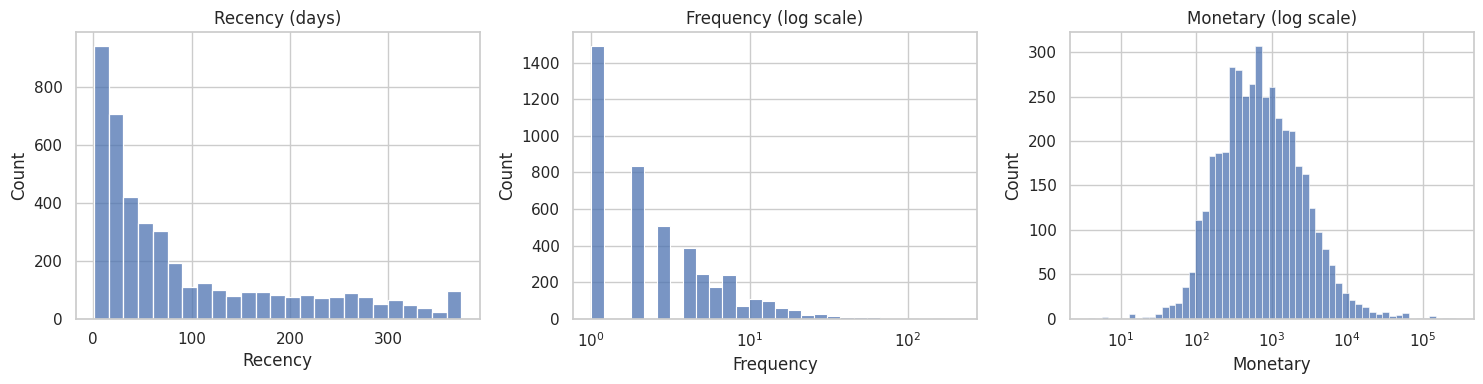

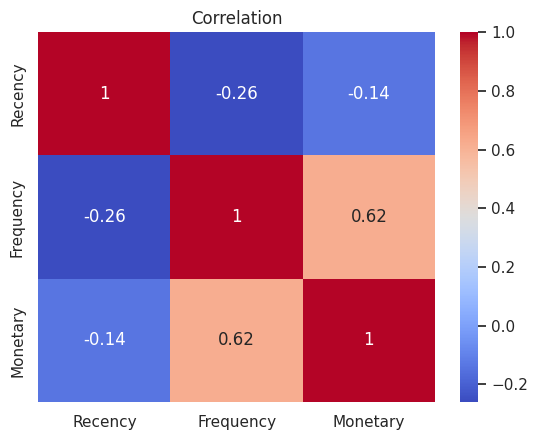

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm["Recency"], ax=axes[0])
axes[0].set_title("Recency (days)")
sns.histplot(rfm["Frequency"], ax=axes[1], log_scale=True)
axes[1].set_title("Frequency (log scale)")
sns.histplot(rfm["Monetary"], ax=axes[2], log_scale=True)
axes[2].set_title("Monetary (log scale)")
plt.tight_layout()
plt.show()

sns.heatmap(table.corr().round(2), annot=True, cmap="coolwarm")
plt.title("Correlation")
plt.show()

          Country      Monetary  Population
0  United Kingdom  6.721666e+06  62348447.0
1     Netherlands  2.782904e+05  16645000.0
2            EIRE  2.593484e+05         NaN
3         Germany  2.286784e+05  81802257.0
4          France  2.013735e+05  64768389.0


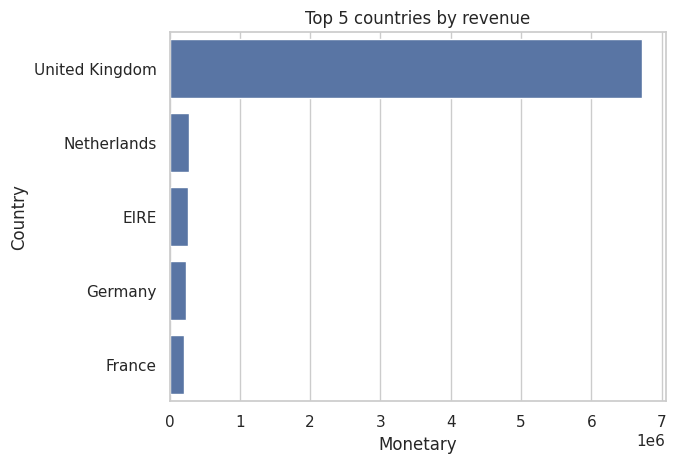

In [22]:
# top 5 countries by money spent, with the scraped population
top = rfm.groupby("Country")["Monetary"].sum().sort_values(ascending=False).head(5).reset_index()
top = top.merge(countries, on="Country", how="left")      # EIRE / USA names may not match -> empty
print(top)

sns.barplot(data=top, x="Monetary", y="Country")
plt.title("Top 5 countries by revenue")
plt.show()

## 7. Probability

In [23]:
limit = np.percentile(rfm["Monetary"], 75)
high = rfm["Monetary"] > limit
uk = rfm["IsUK"] == 1

print("P(High spender) =", round(high.mean(), 3))
print("P(High | UK)    =", round(high[uk].mean(), 3))
print("P(at least 3 of 10 are high spenders) =", round(1 - stats.binom.cdf(2, 10, high.mean()), 3))

P(High spender) = 0.25
P(High | UK)    = 0.238
P(at least 3 of 10 are high spenders) = 0.475


## 8. Machine learning: KMeans clustering

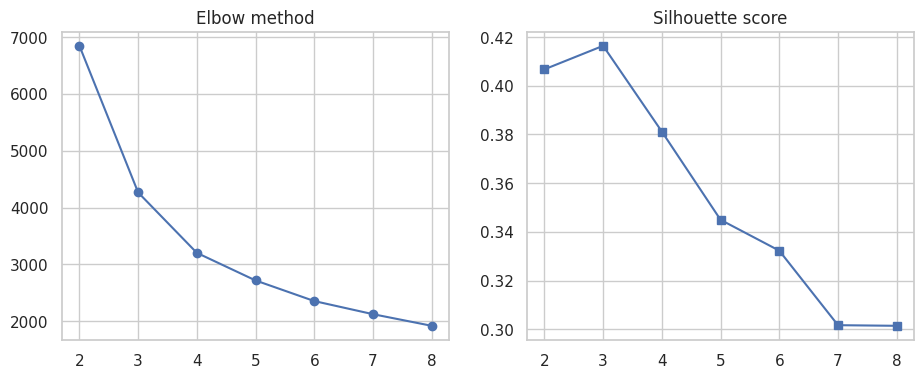

In [24]:
data = rfm[["Recency", "Frequency", "Monetary"]].copy()
data["Frequency"] = np.log1p(data["Frequency"])
data["Monetary"] = np.log1p(data["Monetary"])
X = StandardScaler().fit_transform(data)

inertia = []
silhouette = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X, model.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(2, 9), inertia, "o-")
axes[0].set_title("Elbow method")
axes[1].plot(range(2, 9), silhouette, "s-")
axes[1].set_title("Silhouette score")
plt.show()

In [25]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X)
rfm["Cluster"] = kmeans.labels_

# name the groups from lowest to highest average spending
order = rfm.groupby("Cluster")["Monetary"].mean().sort_values().index
rfm["Segment"] = rfm["Cluster"].map(dict(zip(order, ["Low value", "Occasional", "Loyal", "Champions"])))

# summary table
summary = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean().round(1)
summary["Customers"] = rfm["Segment"].value_counts()
summary["Revenue"] = rfm.groupby("Segment")["Monetary"].sum().round(1)
summary["Revenue_%"] = (summary["Revenue"] / summary["Revenue"].sum() * 100).round(1)
summary.sort_values("Revenue", ascending=False)

,Recency,Frequency,Monetary,Customers,Revenue,Revenue_%
Segment,,,,,,
Champions,18.9,16.1,9137.2,555,5071147.4,61.2
Loyal,45.9,4.3,1591.1,1459,2321417.2,28.0
Occasional,58.0,1.5,386.2,1385,534880.1,6.5
Low value,259.5,1.4,379.5,939,356366.2,4.3


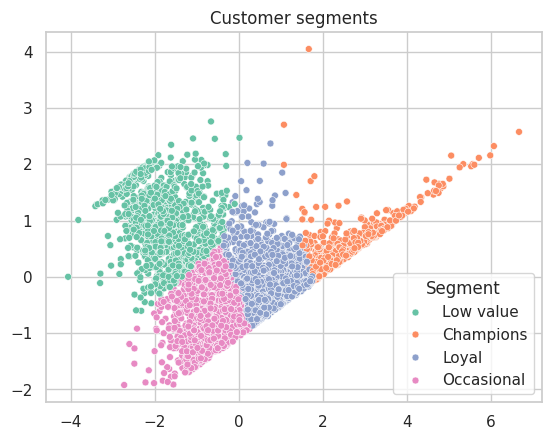

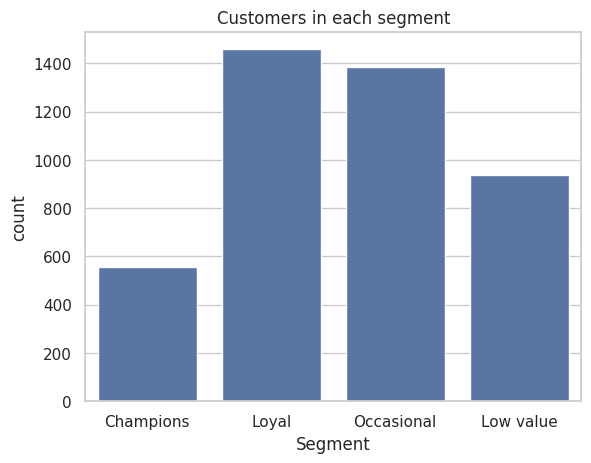

In [26]:
# draw the groups on a 2D picture
points = PCA(n_components=2).fit_transform(X)
sns.scatterplot(x=points[:, 0], y=points[:, 1], hue=rfm["Segment"], palette="Set2", s=25)
plt.title("Customer segments")
plt.show()

sns.countplot(data=rfm, x="Segment", order=["Champions", "Loyal", "Occasional", "Low value"])
plt.title("Customers in each segment")
plt.show()

## 9. Sampling, inference and hypothesis testing (SciPy)

In [27]:
sample = rfm.sample(200, random_state=1)
print("Mean Monetary - all customers :", round(rfm["Monetary"].mean(), 2))
print("Mean Monetary - sample of 200  :", round(sample["Monetary"].mean(), 2))

# Confidence interval
low, high_ci = stats.t.interval(0.95, len(sample) - 1, loc=sample["Monetary"].mean(), scale=stats.sem(sample["Monetary"]))
print(f"95% confidence interval from the sample: {low:.0f} to {high_ci:.0f}")

Mean Monetary - all customers : 1909.59
Mean Monetary - sample of 200  : 1545.54
95% confidence interval from the sample: 1123 to 1969


In [28]:
uk_money = rfm[rfm["IsUK"] == 1]["Monetary"]
other_money = rfm[rfm["IsUK"] == 0]["Monetary"]
p1 = stats.ttest_ind(uk_money, other_money, equal_var=False).pvalue

groups = [g["Monetary"] for _, g in rfm.groupby("Segment")]
p2 = stats.f_oneway(*groups).pvalue

p3 = stats.chi2_contingency(pd.crosstab(rfm["IsUK"], rfm["Segment"]))[1]

for name, p in [("t-test", p1), ("ANOVA", p2), ("Chi-square", p3)]:
    print(name, "p =", round(p, 4), "->", "reject H0" if p < 0.05 else "fail to reject H0")

t-test p = 0.0172 -> reject H0
ANOVA p = 0.0 -> reject H0
Chi-square p = 0.0461 -> reject H0


## 10. Python core concepts and data structures

In [29]:
def customer_type(money):
    if money >= 5000:
        return "Gold"
    elif money >= 1000:
        return "Silver"
    else:
        return "Bronze"

rfm["Type"] = rfm["Monetary"].apply(customer_type)
print(rfm["Type"].value_counts())

for segment in ["Champions", "Loyal", "Occasional", "Low value"]:
    print(f"{segment:<12} -> {my_utils.offer(segment)}")

# lambda and list comprehension
double = lambda x: x * 2
big_spenders = [int(c) for c in rfm[rfm["Monetary"] > 10000]["CustomerID"]]
print("double(5) =", double(5), "| customers who spent more than 10000:", len(big_spenders))

Type
Bronze    2681
Silver    1388
Gold       269
Name: count, dtype: int64
Champions    -> Early access and loyalty points
Loyal        -> Bundle discount
Occasional   -> 10% coupon
Low value    -> Win-back voucher
double(5) = 10 | customers who spent more than 10000: 96


In [30]:
top_ids = rfm.nlargest(5, "Monetary")["CustomerID"].tolist()      # LIST   (changeable, ordered)
first = (int(rfm["Recency"][0]), int(rfm["Frequency"][0]))        # TUPLE  (cannot be changed)
all_countries = set(rfm["Country"])                               # SET    (only unique values)
per_country = rfm["Country"].value_counts().head(3).to_dict()     # DICT   (key: value)

print("list :", top_ids)
print("tuple:", first)
print("set  :", len(all_countries), "different countries")
print("dict :", per_country)

list : [14646, 18102, 14911, 17450, 12415]
tuple: (326, 1)
set  : 37 different countries
dict : {'United Kingdom': 3920, 'Germany': 94, 'France': 87}


## 11. Save the results (file handling)

In [31]:
rfm.to_csv("customers_segmented.csv", index=False)

with open("segment_summary.json", "w") as file:
    json.dump(summary.reset_index().to_dict(orient="records"), file, indent=4)

with open("report.txt", "w") as file:
    for segment, row in summary.sort_values("Revenue", ascending=False).iterrows():
        file.write(f"{segment}: {int(row['Customers'])} customers, {row['Revenue_%']}% of revenue -> {my_utils.offer(segment)}\n")

print(open("report.txt").read())

try:
    from google.colab import files
    files.download("customers_segmented.csv")
except ImportError:
    print("Files saved in the notebook folder")

Champions: 555 customers, 61.2% of revenue -> Early access and loyalty points
Loyal: 1459 customers, 28.0% of revenue -> Bundle discount
Occasional: 1385 customers, 6.5% of revenue -> 10% coupon
Low value: 939 customers, 4.3% of revenue -> Win-back voucher



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>